# Predicting Airbnb Listing Prices in Tokyo

## Executive Summary
This project investigates the various factors that can influence Airbnb listing prices in Tokyo, Japan, with a focus on property amenities. 

By using Airbnb listing data, data cleaning, exploratory data analysis, feature engineering, statistical testing, predictive modeling, and model explainability techniques were applied to understand pricing patterns and the relative importance of different listing characteristics. 

**Key findings include:**
- Property characteristics such as accommodation capacity, number of bedrooms, room type, and neighborhood were the strongest predictors of price.
- Premium amenities such as pools, gyms, and hot tubs were associated with substantial price premiums.
- Common amenities such as air conditioning and washing machines showed little impact, implying that there are often times baseline expectations.
- A Random Forest model achieved the strongest predictive performance ($R^2 = 0.73$ and $RMSE = 0.38$ on log-transformed price data.
- SHAP analysis confirmed that accomodation capacity, neighborhood, and listing availability were the most influential drivers of predicted prices.

Overall, the analysis demonstrates that while amenities contribute to listing value, broader property characteristics and location remain the primary determinants of Airbnb pricing in Tokyo.

## Table of Contents
1. [Introduction](#1.-Introduction)
2. [Data Loading and Overview](#2.-Data-Loading-and-Overview)
3. [Data Cleaning](#3.-Data-Cleaning)
4. [Exploratory Data Analysis](#4.-Exploratory-Data-Analysis-(EDA))
5. [Feature Engineering](#5.-Feature-Engineering)
6. [Modeling and Evaluation](#6.-Modeling-and-Evaluation)
7. [Model Explainability (SHAP)](#7.-Model-Explainability-(SHAP))
8. [Conclusions and Next Steps](#8.-Conclusion-and-Next-Steps)

## 1. Introduction
Tokyo is one of the most visited cities in the world, with a very competitive short-term rental space. This project analyzes Airbnb listings in Tokyo to identify key drivers of price variation and builds models to predict listing prices and price category based on property characteristics and amenities.<br><br>
**Objectives**
1. Predict listing prices (regression)
2. Understand which features affect pricing (feature selection)


**About the Dataset**<br>
- 2 datasets were downloaded via [Kaggle](https://www.kaggle.com/datasets/tsarromanov/tokyo-airbnb-open-data).
- The first, *listings*, has 11177 unique listings with 75 columns.
- The second, *reviews*, has 407712 unique reviews with 6 columns.
- The data contains listing and review information up to 29 June, 2023.

**Modeling Objectives**<br>
- Use regression to determine Airbnb listing price
- Use classification to sort listings into price "bins" 

In [1]:
# === Standard Library ===
import os
import re
import ast
import json
import time
import logging
import inspect
import warnings
from collections import Counter
from IPython.display import display

# === Data Handling & Computation ===
import numpy as np
import pandas as pd

# === Visualization ===
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# === Machine Learning ===
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# === Regression Models ===
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# === Classification Models ===
from sklearn.neighbors import KNeighborsClassifier

# === Metrics & Model Evaluation ===
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance
import shap

# === Configuration ===
warnings.filterwarnings("ignore")
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

## 2. Data Loading and Overview
Once the Airbnb dataset was loaded, the structure and content of the data were explored.
**Key steps:**
- Loaded listing and review dataset using **pandas**
- Inspected the data shape and column names
- Displayed sample rows using **df.head()** to inspect possible values
- Checked for missing values and data types using **df.info()** and **df.isna().sum()**

**Data Summary**<br>
The *listings* dataset includes 70+ variables which can be grouped into seven categories: listing identifiers & metadata, descriptive information, host information, location features, property structure, pricing & availabilty, and review metrics.

| Category | Number of Columns | Example Column | Purpose |
| :--- | :--- | :--- | :--- |
| Listing Identifiers | 5 | id | Uniquely identifies listings |
| Descriptive Information | 8 | amenities | Captures property attributes for feature engineering |
| Host Information | 22 | host_response_time | Shows host characteristics and portfolio size |
| Location Features | 5 | neighborhood | Provides geographical and neighborhood information which may influence location-driven pricing |
| Property Structure | 5 | accommodates | Describes physical characteristics, serving as a basis for predictors and price  |
| Pricing & Availability | 16 | price | Defines pricing structure and business variables |
| Review Metrics | 13 | number_of_reviews | Highlights customer satisfaction |

The *reviews* dataset includes 6 variables which can be grouped into identifiers, metadata, and review content. It is important to note that *reviews* contains foreign keys to tie reviews to specific listings, as well as reviews to specific reviewers.

In [2]:
# Load Airbnb data
listings_df = pd.read_csv("listings.csv")

# Load Airbnb review data
reviews_df = pd.read_csv("reviews.csv")
pd.options.display.max_columns = None

## 3. Data Cleaning
Before analysis, inconsistencies, missing values, and formatting issues had to be addressed.    
**Key steps**
- Converted price from str to float
- Removed or imputed missing values in columns such as `beds` and `bedrooms`
- Converted dates to datetime objects for time-series analysis
- Standardized text and categorical labels (e.g., `room_type`, `bathroom_type`)
- Normalized the structure of nested or list-like columns (e.g. `amenities`)  
Cleaning ensures that the dataset (which is often noisy) is reliable, consistent, and ready for exploration and modeling.

In [3]:
# Convert "neighbourhood" to "neighborhood" for consistency
listings_df = listings_df.rename(columns={"neighbourhood_cleansed" : "neighborhood_cleansed"})

In [4]:
# Convert to float, include a log-scale price column
listings_df["price"] = listings_df["price"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
listings_df = listings_df[listings_df["price"] > 0]
listings_df["log_price"] = np.log1p(listings_df["price"])

Due to the highly right-skewed distribution of price, a log transformation (log1p) was applied to stabilize variance and reduce the influence of extreme values. The log1p function was chosen to safely handle potential zero values in the dataset.

In [5]:
# Fill listings with "nan" for beds or bedrooms to 0
listings_df.loc[:,"bedrooms"] = listings_df.loc[:,"bedrooms"].fillna(0)
listings_df.loc[:,"beds"] = listings_df.loc[:,"beds"].fillna(0)

About 17% of listings have bedrooms as null values, while about 4% of listings have beds as null values. This can be an error in the data and/or a difference in culture. For example, the use of futons vs beds, renting out a bedroom of a house, or lack of a private bedroom (such as in a hostel).

In [6]:
# Convert to datetime 
reviews_df["date"] = pd.to_datetime(reviews_df["date"])
reviews_df["review_month"] = reviews_df["date"].dt.month
listings_df["last_review"] = pd.to_datetime(listings_df["last_review"].astype(str), errors="coerce")

In [7]:
def extract_bath_count(text):
    """Return the number of bathrooms. """
    if pd.isna(text):
        return 0
    if "half" in text.lower():
        return 0.5
    match = re.search(r"(\d+(\.\d+)?)", text)
    return float(match.group(1)) if match else np.nan

def extract_bath_type(text):
    """Return the type of bathroom. """
    if pd.isna(text):
        return "none"
    text = text.lower()
    if "shared" in text:
        return "shared"
    elif "private" in text:
        return "private"
    else:
        return "private"  # assume private if not stated

listings_df.loc[:,"bathroom_count"] = listings_df.loc[:,"bathrooms_text"].apply(extract_bath_count)
listings_df.loc[:,"bathroom_type"] = listings_df.loc[:,"bathrooms_text"].apply(extract_bath_type)

Prior to cleaning, bathroom information was combined into one column. But separating, into type and number of bathrooms, allows for more in-depth investigation to see which individual factors are attributed to certain variables. 

## 4. Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) was conducted to understand distribution properties, identify outliers, and evaluate relationships between listing attributes and price.
**Key insights:**
- Price distribution was highly right-skewed, motivating a log transformation
- `review_scores_rating` has very little variance (many highly rated listings, even when compared against different columns)
- Spatial analysis shows many listings centered in a general area with most listings appearing in Shinjuku
- Temporal trends in `last_review` showed seasonality and variation over time
- There are more hosts with only one listing, however this is a small group of hosts with a lot more than one listing  (mean: 4, median: 2)
- Specific amenities are correlated with higher priced listings

EDA provided a foundation for understanding the dataset and informed later modeling decisions.

In [8]:
# Choosing a subset of columns for analysis
select_columns = [
        "host_id",
        "price", "log_price",
      
        "accommodates", "bedrooms", "beds", "bathroom_count", "bathroom_type",
        "room_type", "property_type", "amenities",
    
        "number_of_reviews", "reviews_per_month",
        "review_scores_rating", "last_review",
    
        "availability_365",
    
        "neighborhood_cleansed",
        "latitude",
        "longitude"
]
selected_listings_df = listings_df[select_columns]

### 4.1. Price Structure and Distribution

This section focuses on understanding the distribution and drivers of listing prices. Prices across different listing characteristics, including room type, location, and capacity were examined. Due to the highly right-skewed nature of price data, a log transformation is applied to stabilize variance and enable more meaningful comparisons. These analyses help identify key factors influencing pricing and inform feature selection for subsequent modeling.

In [9]:
mean_price = selected_listings_df["price"].mean().round(2)
median_price = selected_listings_df["price"].median().round(2)
mode_price = selected_listings_df["price"].mode().round(2)[0]
avg = {
    "Mean": [mean_price],
    "Median": [median_price],
    "mode": [mode_price]
}
avg_df = pd.DataFrame(avg)
avg_df.head()

,Mean,Median,mode
0,21802.12,14429.0,50000.0


The large gap between mean and median confirms a strong right skew in pricing. The mode being $50,000 suggests price clustering at the luxury level.

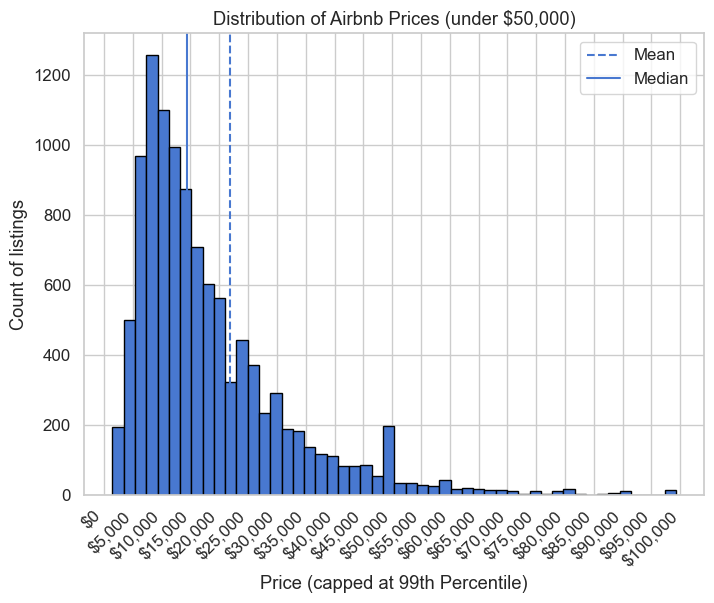

In [10]:
upper_cap = selected_listings_df["price"].quantile(0.99)

plt.figure(figsize=(8,6))
plt.hist(selected_listings_df[selected_listings_df["price"] < upper_cap]["price"], bins=50, edgecolor="black")
plt.xlabel("Price (capped at 99th Percentile)")

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5000))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))

plt.xticks(rotation=45, ha="right")
plt.ylabel("Count of listings")
plt.title("Distribution of Airbnb Prices (under $50,000)")
plt.axvline(mean_price, linestyle="--", label="Mean")
plt.axvline(median_price, linestyle="-", label="Median")
plt.legend()
plt.show()

Implication: The skewed pricing structure suggests that most listings target mid-range travelers, while a smaller subset caters to premium segments.

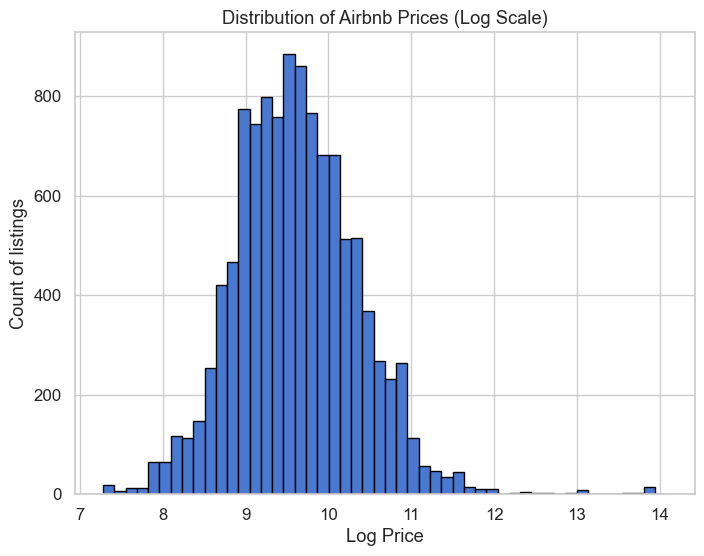

In [11]:
plt.figure(figsize=(8,6))
plt.hist(selected_listings_df["log_price"], bins=50, edgecolor="black")
plt.xlabel("Log Price")
plt.ylabel("Count of listings")
plt.title("Distribution of Airbnb Prices (Log Scale)")
plt.show()

After applying a log transformation on price, the distribution approximates a normal distribution.

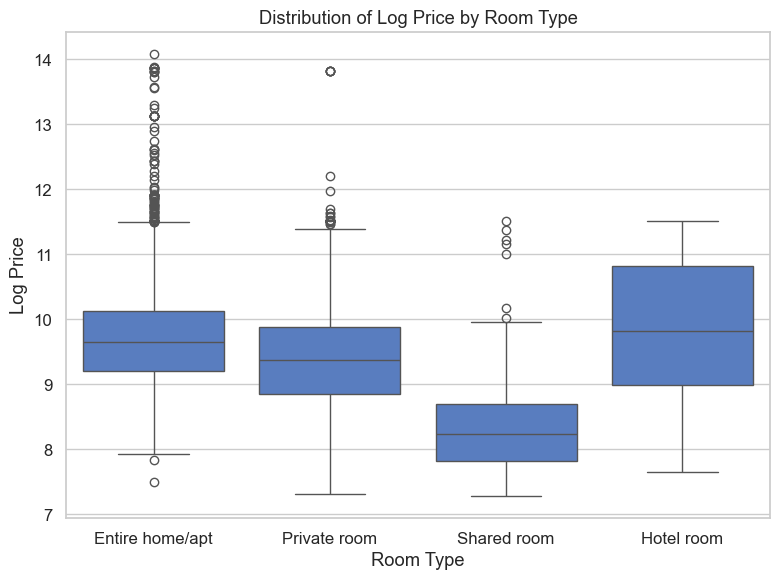

In [12]:
# Price by room type
plt.figure(figsize=(8,6))
sns.boxplot(x=selected_listings_df["room_type"], y=selected_listings_df["log_price"])
plt.xlabel("Room Type")
plt.ylabel("Log Price")
plt.title("Distribution of Log Price by Room Type")
plt.tight_layout()
plt.savefig(
    "images/room_type_prices.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

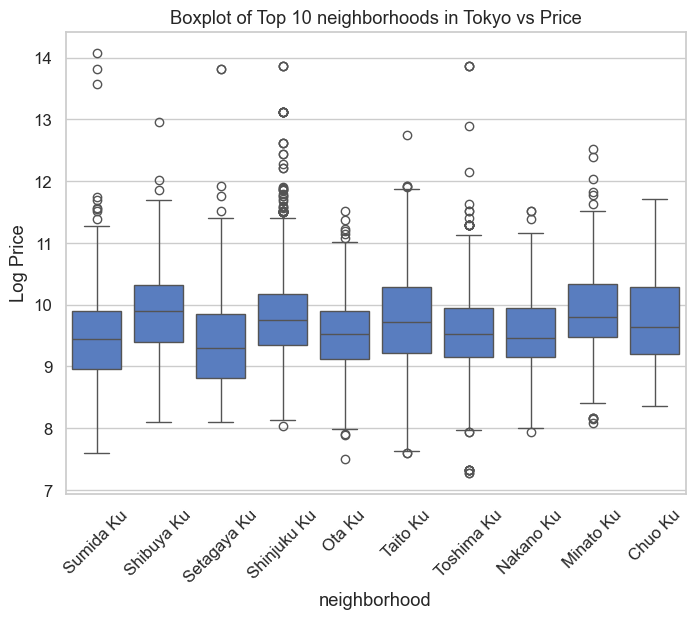

In [13]:
plt.figure(figsize=(8,6))
top_neighborhoods = selected_listings_df["neighborhood_cleansed"].value_counts().head(10).index
sns.boxplot(
    data=selected_listings_df[selected_listings_df["neighborhood_cleansed"].isin(top_neighborhoods)],
    x="neighborhood_cleansed",
    y="log_price"
)

plt.xticks(rotation=45)
plt.title("Boxplot of Top 10 neighborhoods in Tokyo vs Price")
plt.xlabel("neighborhood")
plt.ylabel("Log Price")
plt.show()

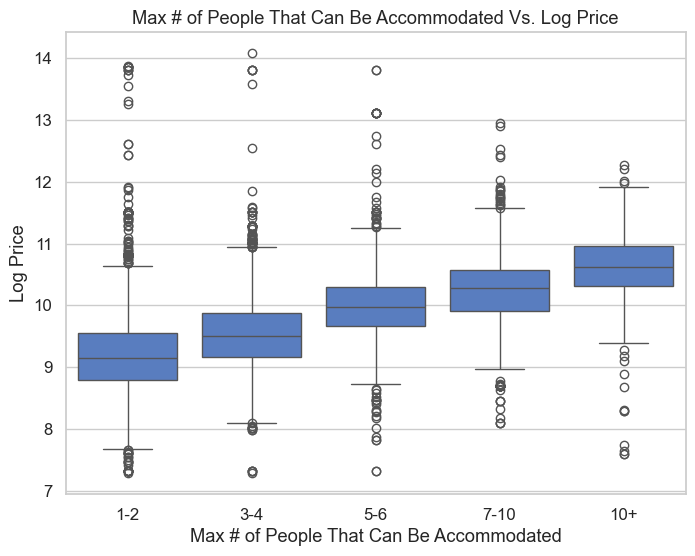

In [14]:
plt.figure(figsize=(8,6))
selected_listings_df["accommodates_group"] = pd.cut(
    selected_listings_df["accommodates"],
    bins=[0,2,4,6,10,20],
    labels=["1-2","3-4","5-6","7-10","10+"]
)

sns.boxplot(
    data=selected_listings_df,
    x="accommodates_group",
    y="log_price"
)

plt.xlabel("Max # of People That Can Be Accommodated")
plt.ylabel("Log Price")
plt.title("Max # of People That Can Be Accommodated Vs. Log Price")
plt.show()

**Key Insights**
- Shared rooms have the lowest median price.
- Hotel rooms on average command higher prices, though there are outliers across room types.
- Prices do vary depending on location, with certain neighborhoods having higher median prices.
- As the number of people increases, the price increases as well. Though there are plenty of outliers as well.

### 4.2. Review and Rating Behavior

This section explores how user engagement and satisfaction relate to listing characteristics. Specifically, review frequency, rating distributions, and their relationship with price and location were analyzed. Understanding these patterns helps identify whether higher-priced listings correspond to better user experiences and stronger demand signals.

In [15]:
mean_reviews_per_month = selected_listings_df["reviews_per_month"].mean().round(2)

#### Average number of Reviews Per Month: 1.47 

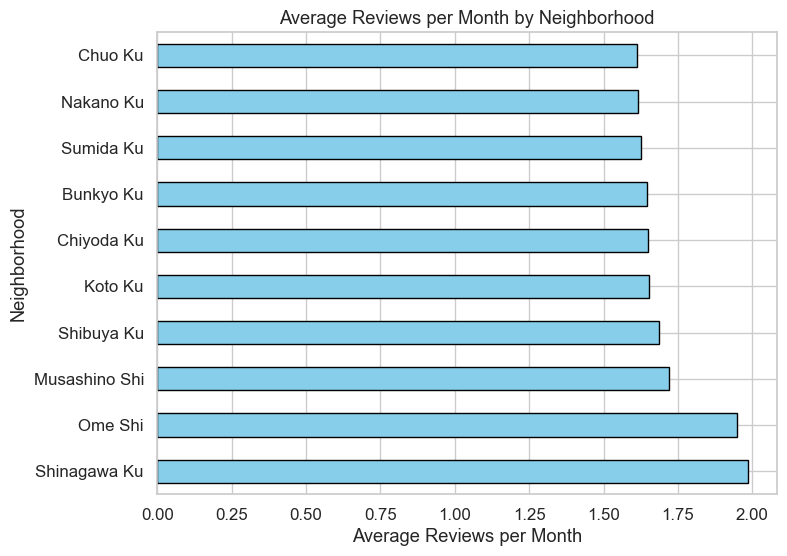

In [16]:
# Look at reviews/month by neighborhood cleansed 
plt.figure(figsize=(8,6))
reviews_by_neighborhood = (
    selected_listings_df
    .groupby("neighborhood_cleansed")["reviews_per_month"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

reviews_by_neighborhood.plot(kind="barh", color="skyblue", edgecolor="black")
plt.xlabel("Average Reviews per Month")
plt.ylabel("Neighborhood")
plt.title("Average Reviews per Month by Neighborhood")
plt.show()

Review activity varies significantly across neighborhoods, indicating differences in demand and listing turnover. High-review areas likely represent high-traffic tourist zones or competitively priced listings.

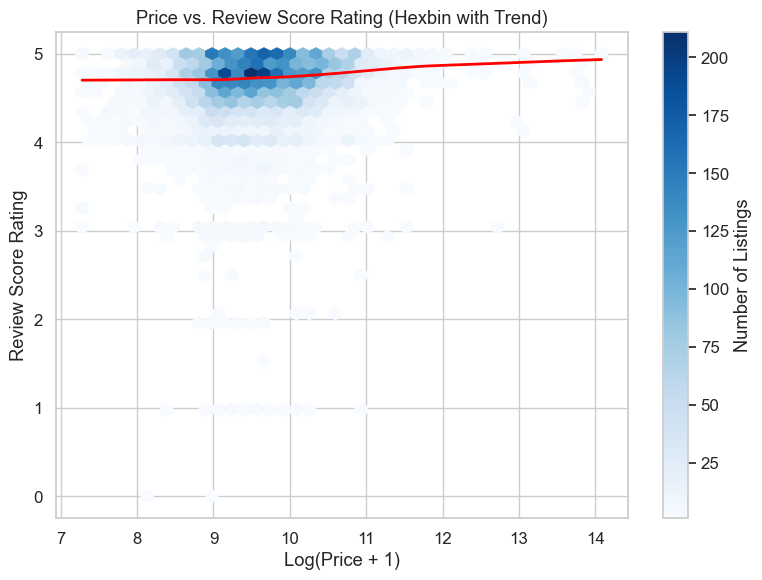

In [17]:
x_val = selected_listings_df["log_price"]
y_val = selected_listings_df["review_scores_rating"]
plt.figure(figsize=(8,6))

# Hexbin plot (density of points)
hb = plt.hexbin(
    x_val, y_val, 
    gridsize=40, cmap="Blues", mincnt=1, linewidths=0.5
)
plt.colorbar(hb, label="Number of Listings")

# Regression line (lowess = locally weighted smoothing)
sns.regplot(
    x=x_val, y=y_val, 
    scatter=False,  # don’t double-plot points
    line_kws={"color":"red", "lw":2},
    lowess=True
)

# Labels and formatting
plt.xlabel("Log(Price + 1)")
plt.ylabel("Review Score Rating")
plt.title("Price vs. Review Score Rating (Hexbin with Trend)")
#plt.ylim(0,5)   # zoom in to useful rating range
plt.tight_layout()
plt.show()

Ratings are heavily concentrated at the high end (4.5–5.0), indicating limited variance in customer satisfaction. The weak relationship between price and rating suggests that higher-priced listings do not necessarily guarantee better reviews.

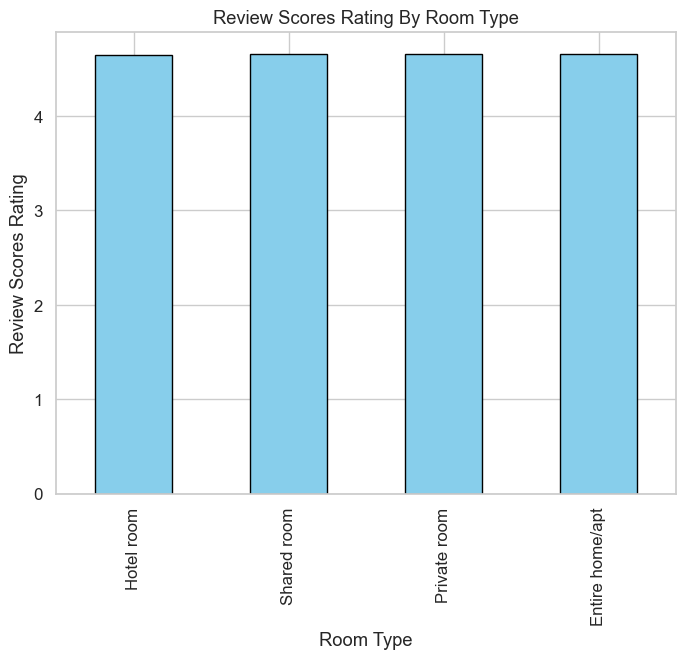

In [18]:
reviews_by_room_type = selected_listings_df.groupby("room_type")["review_scores_rating"].mean().sort_values()
plt.figure(figsize=(8,6))
reviews_by_room_type.plot(kind="bar", color="skyblue", edgecolor="black")
plt.xlabel("Room Type")
plt.ylabel("Review Scores Rating")
plt.title("Review Scores Rating By Room Type")
plt.show()
rev_room_type_df = pd.DataFrame(reviews_by_room_type)

Average ratings are consistently high across all room types, with minimal variation. This suggests that listing type has little impact on perceived guest satisfaction, reinforcing the overall positive bias in review scores.

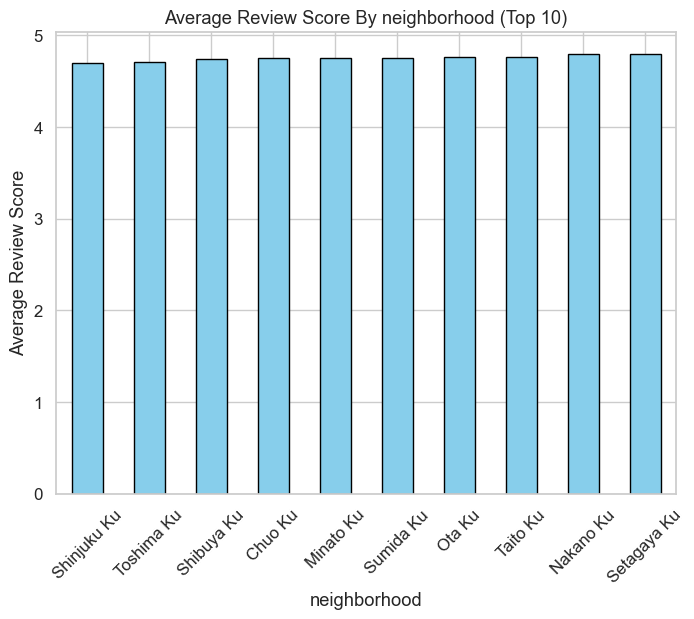

In [19]:
top_neighborhoods = (
    selected_listings_df["neighborhood_cleansed"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(8,6))

ratings_by_neighborhood = (
    selected_listings_df[
        selected_listings_df["neighborhood_cleansed"].isin(top_neighborhoods)
    ]
    .groupby("neighborhood_cleansed")["review_scores_rating"]
    .median()
    .sort_values()
)

ratings_by_neighborhood.plot(kind="bar", color="skyblue", edgecolor="black")
plt.xlabel("neighborhood")
plt.ylabel("Average Review Score")
plt.title("Average Review Score By neighborhood (Top 10)")
plt.xticks(rotation=45)
plt.show()

Rating differences across neighborhoods are minimal, suggesting that location does not significantly impact guest satisfaction. This further highlights the limited variability in rating data.

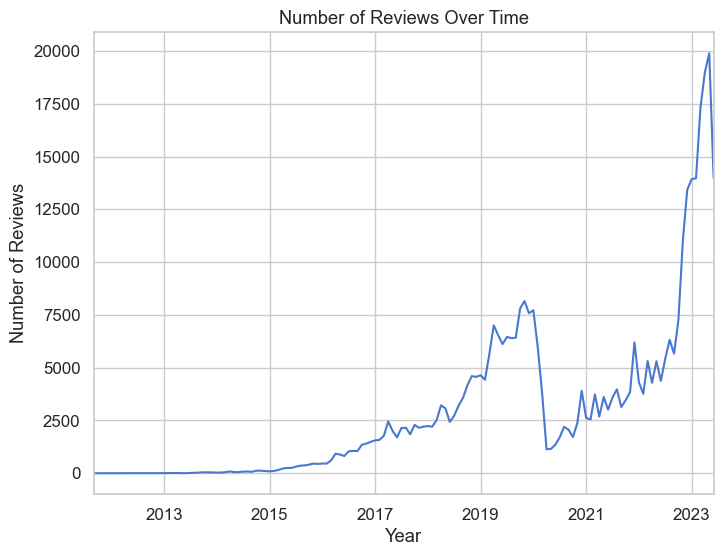

In [20]:
# Month End
reviews_by_month = reviews_df.resample("ME", on="date").size()
reviews_by_month = reviews_df.resample("ME", on="date").size()
reviews_by_month.plot(figsize=(8,6))
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews Over Time")
plt.show()

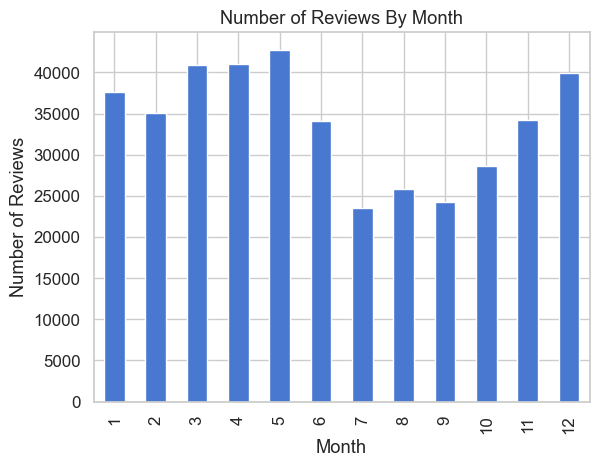

In [21]:
reviews_df.groupby("review_month")["id"].count().plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews By Month")
plt.show()

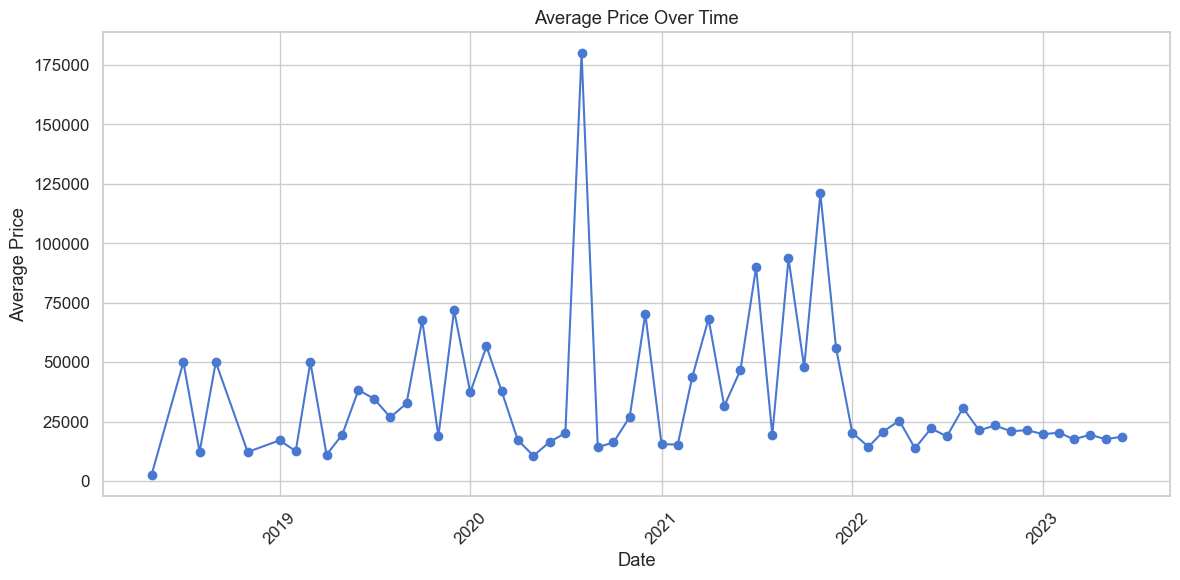

In [22]:
# drop rows with no reviews
df_reviews = selected_listings_df.dropna(subset=["last_review"])

# group by year-month
reviews_over_time = (
    df_reviews
    .groupby(df_reviews["last_review"].dt.to_period("M"))["price"]
    .mean()
)

# convert PeriodIndex to datetime for plotting
reviews_over_time.index = reviews_over_time.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(reviews_over_time.index, reviews_over_time.values, marker="o", linestyle="-")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.title("Average Price Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Key Insights**
- Possible postive bias reinforced in review scores supported by review scores seemingly being unaffected by listing prices.
- Reviews scores show little variance (4.5-5.0) across multiple variables (ie. room type, neighborhood).
- The amount of reviews reinforce clear seasonal patterns.

### 4.3. Geographic and Market Concentration

This section examines the geographic distribution of listings and how location influences both supply and pricing. Analyzing neighborhood-level concentration as well as spatial patterns allows for additional insight into why there is varied pricing across neighborhoods.

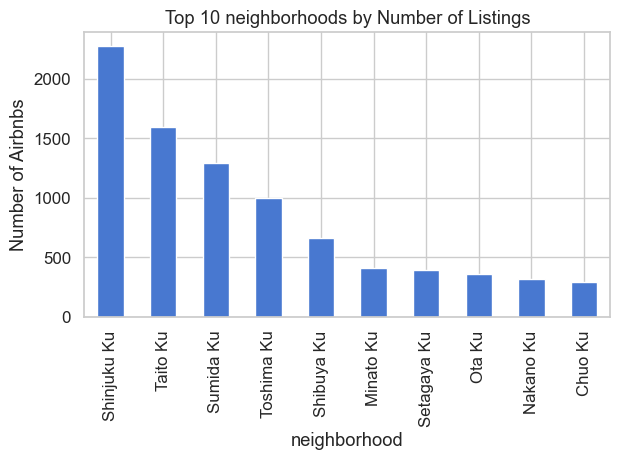

In [23]:
neighborhood_counts = (
    selected_listings_df["neighborhood_cleansed"]
    .value_counts()
    .head(10)
)

neighborhood_counts.plot(kind = "bar", title = "Top 10 neighborhoods by Number of Listings")
plt.xlabel("neighborhood")
plt.ylabel("Number of Airbnbs")
plt.xticks(rotation=90) 
plt.tight_layout()
plt.show()

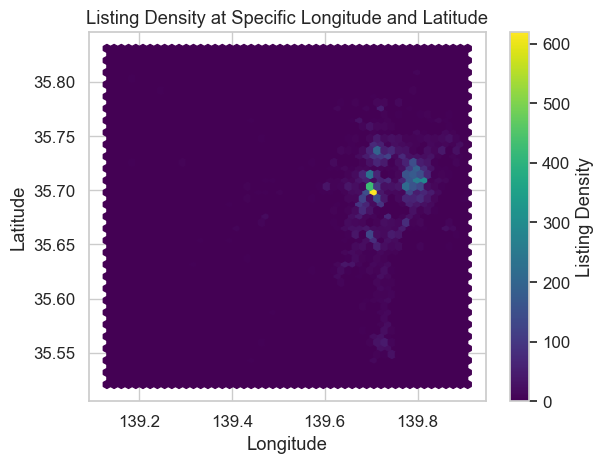

In [24]:
plt.hexbin(
    selected_listings_df["longitude"],
    selected_listings_df["latitude"],
    gridsize=50,
    cmap="viridis"
)

plt.colorbar(label="Listing Density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Listing Density at Specific Longitude and Latitude")
plt.show()

Listings are highly concentrated in a small number of neighborhoods, with areas such as Shinjuku and Taito accounting for a significant share of total supply. This suggests a strong clustering of Airbnb activity in central, high-demand districts.

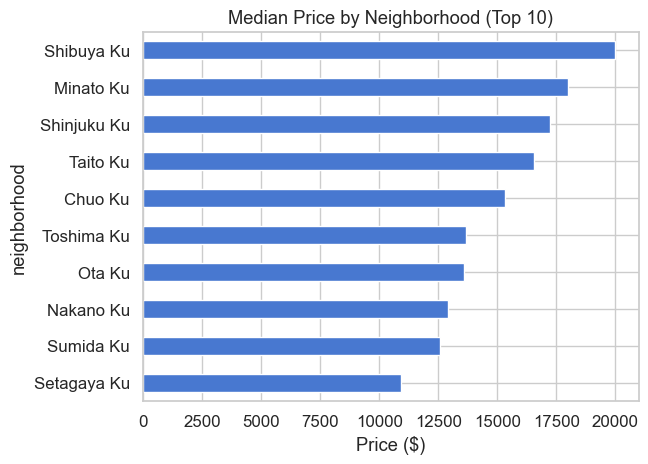

In [25]:
top_neighborhoods = (
    selected_listings_df["neighborhood_cleansed"]
    .value_counts()
    .head(10)
    .index
)

avg_price = (
    selected_listings_df[
        selected_listings_df["neighborhood_cleansed"].isin(top_neighborhoods)
    ]
    .groupby("neighborhood_cleansed")["price"]
    .median()
    .sort_values()
)

avg_price.plot(kind="barh")
plt.title("Median Price by Neighborhood (Top 10)")
plt.xlabel("Price ($)")
plt.ylabel("neighborhood")
plt.show()

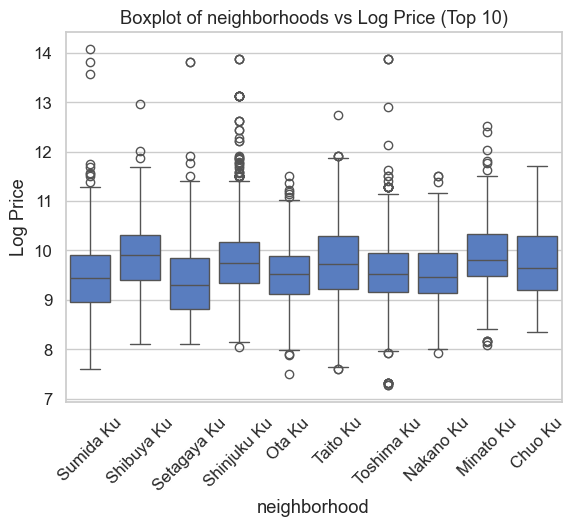

In [26]:
sns.boxplot(
    data=selected_listings_df[selected_listings_df["neighborhood_cleansed"].isin(top_neighborhoods)],
    x="neighborhood_cleansed",
    y="log_price"
)

plt.xticks(rotation=45)
plt.xlabel("neighborhood")
plt.ylabel("Log Price")
plt.title("Boxplot of neighborhoods vs Log Price (Top 10)")
plt.show()

**Key Insights**
- Median prices vary across high-density neighborhoods. Central areas tend to command high prices, reflecting demand, accessibility, and proximity to key attractions.
- The Tokyo Airbnb market is highly concentrated in a small number of central neighborhoods.
- Geographic location is a key driver of supply and price.

### 4.4. Host Analysis

This section explores host behavior and its impact on the Airbnb market. By analyzing how listings are distributed across hosts, it is posible to distinguish between casual hosts and professional operators, and evaluate how host characteristics may influence pricing and supply.

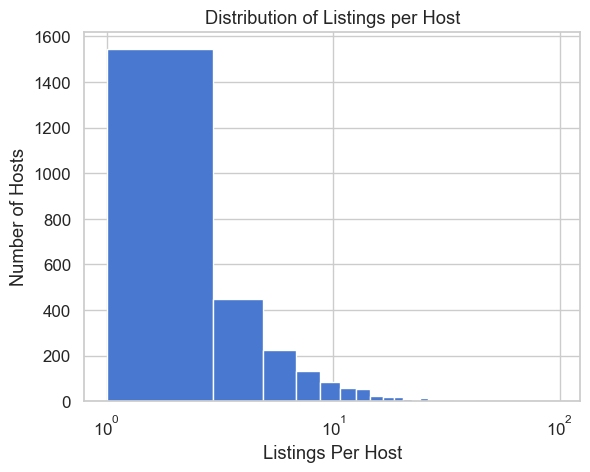

In [27]:
host_listing_counts = selected_listings_df.groupby("host_id").size()

plt.hist(host_listing_counts, bins=50)
plt.title("Distribution of Listings per Host")
plt.xlabel("Listings Per Host")
plt.ylabel("Number of Hosts")
plt.xscale("log")
plt.show()

In [28]:
host_listing_counts = selected_listings_df.groupby("host_id").size()

selected_listings_df["host_listing_count"] = selected_listings_df["host_id"].map(host_listing_counts)

selected_listings_df["host_type"] = selected_listings_df["host_listing_count"].apply(
    lambda x: "Multi-listing host" if x >= 2 else "Single-listing host")

selected_listings_df.groupby("host_type")["price"].median()

host_type
Multi-listing host     14000.0
Single-listing host    19800.0
Name: price, dtype: float64

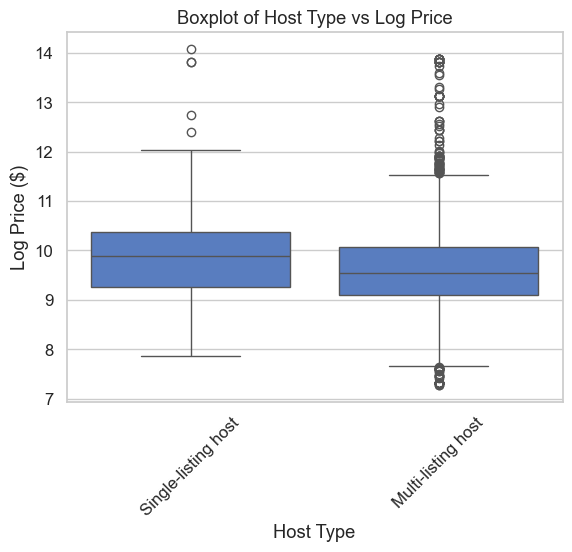

In [29]:
sns.boxplot(
    data=selected_listings_df,
    x="host_type",
    y="log_price"
)

plt.xticks(rotation=45)
plt.xlabel("Host Type")
plt.ylabel("Log Price ($)")
plt.title("Boxplot of Host Type vs Log Price")
plt.show()

**Key Insights**
- Most hosts own only a small number of listings, while a small group of hosts manage a disproportionately large number of properties, indicating the presence of commercial operators.
- Multi-listing hosts tend to operate more professionally and may price listings differently compared to individual hosts, suggesting that host behavior is an important factor in pricing strategy.

### 4.5. Amenity Impact

This section evaluates the impact of amenities on listing price. While raw comparisons provide initial insights, amenities may be correlated with other factors such as location, property size, and host behavior. To isolate the true contribution of amenities, both unadjusted price differences and controlled effects using regression-based approaches were analyzed.

#### 4.5.1. Amenity Cleaning and Feature Preparation

In [30]:
def parse_amenities(x):
    """Parse amenities into list."""
    try:
        return json.loads(x) if isinstance(x, str) else x
    except:
        return []

def decode_unicode(text):
    """Decode unicode escape characters, such as Japanese characters."""
    if isinstance(text, str):
        return text.encode("utf-8").decode("unicode_escape", errors="ignore")
    return text

def normalize_amenity(text):
    """Normalize formating of amenities."""
    text = text.lower().strip()
    text = text.replace("-", " ")   # unify hyphens
    text = text.replace("_", " ")   # unify underscores
    return text

# Amenities synonym mapping
synonyms = {
    "wifi": "wifi",
    "wi fi": "wifi",
    "wireless internet": "wifi",
    "self check in": "self check in",
    "self checkin": "self check in",
    "self check-in": "self check in",
    "gas stove": "stove",
    "window ac unit":"air conditioning",
    "air conditioning": "air conditioning",
    "ac": "air conditioning",
    "tv": "television",
    "free dryer – in unit" : "dryer",
    "free dryer – in building" : "dryer",
    "free dryer" : "dryer",
    "washer" : "washing machine",
    "free washer" : "washing machine",
    "free washer – in unit" : "washing machine",
    "free washer – in building" : "washing machine",
    "free washing machine – in building" : "washing machine",
    "free washing machine – in unit" : "washing machine",
    "free washing machine" : "washing machine",
    "hdtv with netflix, standard cable" : "television",
    "tv with standard cable": "television",
    "television": "television",
    "security cameras on property" : "security cameras",
    "car park": "parking",
    "paid parking off premises": "parking",
    "paid parking lot off premises": "parking",
    "parking lot": "parking",
    "free parking": "parking",
    "paid parking": "parking",
    "parking on premises": "parking",
    "private patio or balcony": "patio or balcony",
    "private patio": "patio or balcony",
    "private balcony": "patio or balcony",
    "patio or balcony": "patio or balcony",
    "patio": "patio or balcony",
    "balcony": "patio or balcony"
}

def unify_synonyms(amenities):
    """Match amenities to a synonym."""
    return [synonyms.get(a, a) for a in amenities]

def clean_amenities(raw):
    """Combines all amenity functions."""
    raw = decode_unicode(raw)                     # fix unicode
    parsed = parse_amenities(raw)                 # parse into list
    normalized = [normalize_amenity(a) for a in parsed]  # normalize
    unified = unify_synonyms(normalized)          # map synonyms
    unique = list(set(unified))                   # remove duplicates
    return unique

# Apply to column
selected_listings_df.loc[:,"amenities_clean"] = selected_listings_df.loc[:,"amenities"].apply(clean_amenities)

#### 4.5.2. Unadjusted Amenity Effects

In [31]:
amenity_counts = Counter([a for sublist in selected_listings_df["amenities_clean"] for a in sublist])
common_amenities = [a for a, c in amenity_counts.most_common(20)]


amenity_coverage = {
    a: np.mean([a in ams for ams in selected_listings_df["amenities_clean"]])
    for a in common_amenities
}

# Pick those between ~20% and 80% coverage
filtered_amenities = [a for a, cov in amenity_coverage.items() if 0.2 <= cov <= 0.8]

In [32]:
# Example: does having "washing machine" impact average price?
def amenity_price_summary(df, amenities_list):
    """
    For each amenity in amenities_list, compute the mean price
    for listings with and without that amenity.

    Args: 
        df (pandas.Dataframe): The Dataframe to be compared.
        amenities_list(list): A list of amenities to compare against.    

    Returns:
        pandas.Dataframe: Comparison Dataframe containing the amenity, 
        the mean price of listings containing the amenity, 
        mean price of listings without the amenity,
        and the different in price.
    """
    results = []

    for amenity in amenities_list:
        has_amenity = selected_listings_df["amenities_clean"].apply(lambda x: amenity in x)

        avg_prices = selected_listings_df.groupby(has_amenity)["price"].mean()

        results.append({
            "Amenity": amenity,
            "Mean price (with)": avg_prices.get(True, np.nan),
            "Mean price (without)": avg_prices.get(False, np.nan),
            "Difference": avg_prices.get(True, 0) - avg_prices.get(False, 0)
        })

    return pd.DataFrame(results).sort_values(by="Difference", ascending=False)

amenities_list = ["television", "heating", "air conditioning", "self check in", "washing machine", "dryer", "parking","patio or balcony",
                 "long term stays allowed", "luggage dropoff allowed", "pool", "hot tub","gym", "dedicated workspace", "pets allowed"]

summary = amenity_price_summary(selected_listings_df,amenities_list)
summary = amenity_price_summary(selected_listings_df, amenities_list)

# Keep only meaningful columns + sort
summary_clean = summary.sort_values("Difference", ascending=False)

# Show top positive and negative separately
top_positive = summary_clean.head(8)
top_negative = summary_clean.tail(8)

display(top_positive.style.format({
    "Mean price (with)": "${:,.0f}",
    "Mean price (without)": "${:,.0f}",
    "Difference": "${:,.0f}"
}).set_caption("Top Amenities Associated with Higher Prices"))

display(top_negative.style.format({
    "Mean price (with)": "${:,.0f}",
    "Mean price (without)": "${:,.0f}",
    "Difference": "${:,.0f}"
}).set_caption("Amenities Associated with Lower Prices"))

,Amenity,Mean price (with),Mean price (without),Difference
10,pool,"$401,800","$21,564","$380,236"
12,gym,"$153,791","$21,459","$132,332"
11,hot tub,"$30,809","$21,554","$9,255"
0,television,"$24,072","$18,056","$6,016"
14,pets allowed,"$25,592","$21,683","$3,909"
6,parking,"$24,703","$21,095","$3,608"
5,dryer,"$23,852","$21,191","$2,661"
9,luggage dropoff allowed,"$23,734","$21,108","$2,626"


,Amenity,Mean price (with),Mean price (without),Difference
9,luggage dropoff allowed,"$23,734","$21,108","$2,626"
1,heating,"$22,272","$20,732","$1,540"
7,patio or balcony,"$22,099","$21,712",$387
3,self check in,"$21,693","$21,928",$-235
4,washing machine,"$21,724","$22,013",$-289
2,air conditioning,"$21,702","$22,260",$-559
8,long term stays allowed,"$21,046","$22,660","$-1,614"
13,dedicated workspace,"$20,264","$22,579","$-2,315"


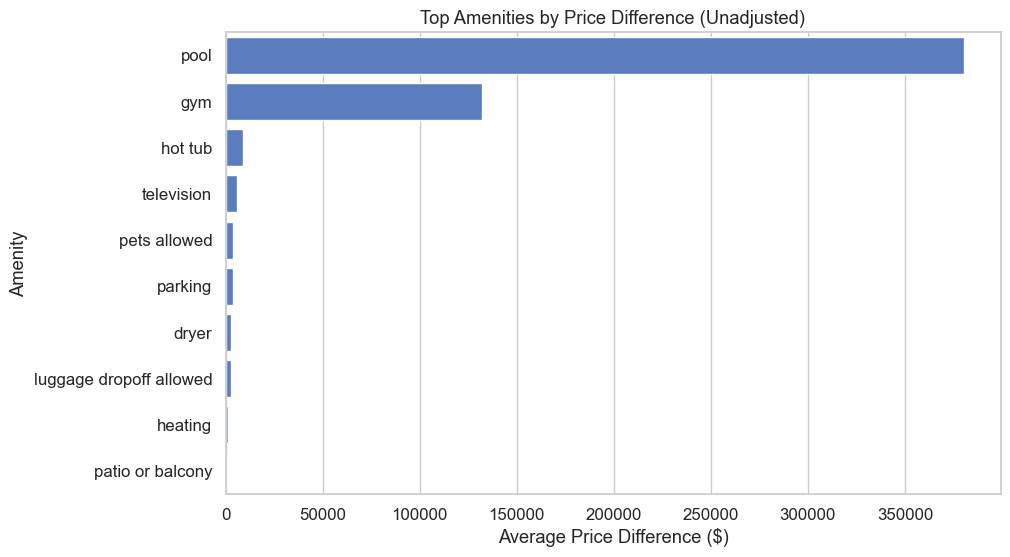

In [33]:
top_diff = summary_clean.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_diff,
    x="Difference",
    y="Amenity"
)
plt.title("Top Amenities by Price Difference (Unadjusted)")
plt.xlabel("Average Price Difference ($)")
plt.ylabel("Amenity")
plt.show()

After computing the mean prices of listings with certain amenities, it is possible to see which amenities have a large influence on the price of the listing, and what, on average is the difference in price. 

In [34]:
fa_df = selected_listings_df[[
        "price", "log_price",
      
        "accommodates", "bedrooms", "beds", "bathroom_count", "bathroom_type",
        "room_type", "property_type", "amenities_clean","number_of_reviews","availability_365",
    
        "neighborhood_cleansed",
        "latitude",
        "longitude"]]

In [35]:
mlb = MultiLabelBinarizer()
amenities_matrix = mlb.fit_transform(fa_df["amenities_clean"])

amenities_df = pd.DataFrame(amenities_matrix, columns=mlb.classes_, index=fa_df.index)
amenities_cols = amenities_df.columns

# Merge with main dataframe
df_with_amenities = pd.concat([fa_df, amenities_df], axis=1)

# Example: correlation with price
correlations = df_with_amenities[amenities_cols].corrwith(df_with_amenities["price"])
correlations = correlations.sort_values(ascending=False)

In [36]:
# Prevalence of each amenity
amenity_prevalence = amenities_df.mean().sort_values(ascending = False) * 100

# Combine with correlation
amenity_stats = pd.DataFrame({
    "CorrelationWithPrice" : correlations,
    "PrevalencePercent" : amenity_prevalence
}).sort_values("CorrelationWithPrice", ascending = False)

# Merge + filter
amenity_stats = pd.DataFrame({
    "Correlation": correlations,
    "Prevalence (%)": amenity_prevalence
})

# Keep only meaningful amenities
filtered_stats = amenity_stats[
    amenity_stats["Prevalence (%)"] >= 5
].sort_values("Correlation", ascending=False)

top_corr = filtered_stats.head(10)
bottom_corr = filtered_stats.tail(10)

display(top_corr.style.format({
    "Correlation": "{:.3f}",
    "Prevalence (%)": "{:.1f}"
}).set_caption("Top Amenities by Correlation with Price"))

display(bottom_corr.style.format({
    "Correlation": "{:.3f}",
    "Prevalence (%)": "{:.1f}"
}).set_caption("Lowest Correlated Amenities"))

,Correlation,Prevalence (%)
television,0.060,62.3
keypad,0.043,12.4
parking,0.030,19.6
private entrance,0.030,43.1
luggage dropoff allowed,0.024,26.4
dryer,0.023,23.0
oven,0.020,6.7
dining table,0.018,18.8
ethernet connection,0.015,11.6
heating,0.015,69.5


,Correlation,Prevalence (%)
dedicated workspace,-0.023,33.6
microwave,-0.027,66.2
cleaning products,-0.028,30.6
host greets you,-0.029,5.0
clothing storage: closet,-0.031,8.2
dishes and silverware,-0.032,63.8
refrigerator,-0.038,70.6
hot water kettle,-0.043,39.9
lockbox,-0.045,30.0
lock on bedroom door,-0.046,12.3


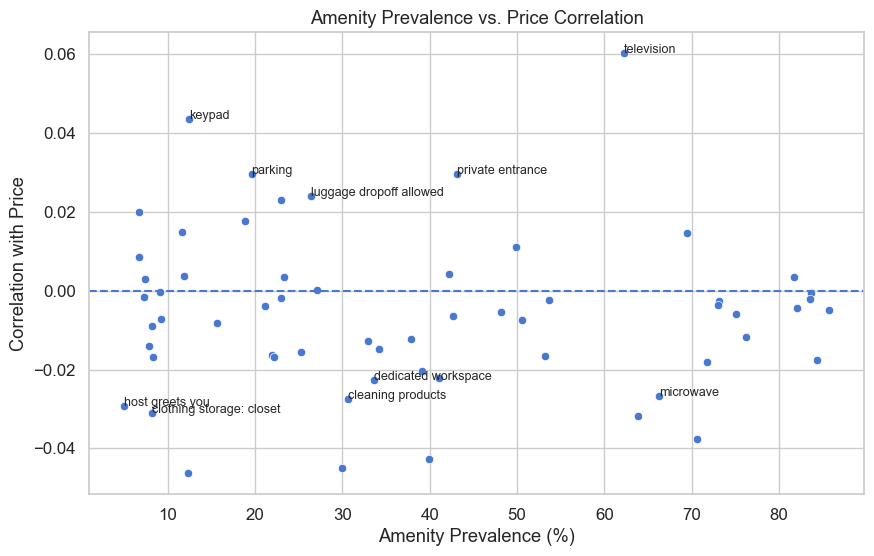

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=filtered_stats,
    x="Prevalence (%)",
    y="Correlation"
)

# Add horizontal line at 0
plt.axhline(0, linestyle="--")

# Annotate key points
for i in top_corr.index[:5]:
    plt.text(
        filtered_stats.loc[i, "Prevalence (%)"],
        filtered_stats.loc[i, "Correlation"],
        i,
        fontsize=9
    )

for i in bottom_corr.index[:-5]:
    plt.text(
        filtered_stats.loc[i, "Prevalence (%)"],
        filtered_stats.loc[i, "Correlation"],
        i,
        fontsize=9
    )

plt.xlabel("Amenity Prevalence (%)")
plt.ylabel("Correlation with Price")
plt.title("Amenity Prevalence vs. Price Correlation")
plt.show()

**Key Insights**
- Premium amenities such as pools, gyms, and hot tubs are associated with substantially higher average listing prices. However, these effects likely reflect the presence of luxury properties rather than the amenities alone driving price increases.
- Practical amenities including televisions, keypads, parking, and private entrances exhibited some of the strongest positive correlations with price, suggesting they may be reliable indicators of higher-value listings.
- Common household amenities such as microwaves, refrigerators, and dishes and silverware showed weak or slightly negative correlations with price, indicating they function as baseline expectations rather than premium differentiators.
- No clear relationship was observed between amenity prevalence and price correlation. Both common and uncommon amenities appeared among the strongest positive and negative correlates of listing price.
- These results are exploratory and unadjusted; amenities may be correlated with other factors such as neighborhood, room type, or property size. Later modeling sections evaluate amenity effects while controlling for these variables.

#### 4.5.3. Controlled Amenity Analysis

In [38]:
# Select features
base_features = [
    "accommodates",
    "bedrooms",
    "bathroom_count",
    "beds"
]

categorical_features = [
    "room_type",
    "neighborhood_cleansed",
    "bathroom_type",
    "property_type"
]

# Choose top amenities
top_amenities = (
    amenity_stats[amenity_stats["Prevalence (%)"] >= 5]
    .sort_values("Correlation", ascending=False)
    .head(10)
    .index
    .tolist()
)

In [39]:
def run_adjusted_amenity_model(df,amenity_list,base_features,categorical_features,target="log_price"):
    """
    Fits a linear regression controlling for
    property size + location + room type,
    then returns and plots amenity coefficients.
    
    Args:
        df (pandas.Dataframe): Original Dataframe to be analyzed.
        amenity_list (list): Amenities to be included.
        base_features (list): Numerical features from original Dataframe to be used.
        categorical_features (list): Categorical features from original Dataframe to be used.
        target (pandas.Series): The target for the model. 

    Returns:
        pandas.Dataframe: Sorted Dataframe of amenities with the highest coefficient, or impact on price.
        
    """

    # combine features
    features = base_features + categorical_features + amenity_list

    X = df[features]
    y = df[target]

    # preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), base_features),
            ("cat", OneHotEncoder(drop="first"), categorical_features)
        ],
        remainder="passthrough"
    )

    # pipeline
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RidgeCV())
    ])

    model.fit(X, y)

    # feature names
    ohe = model.named_steps["preprocessor"]\
               .named_transformers_["cat"]

    cat_names = ohe.get_feature_names_out(categorical_features)

    feature_names = (
        base_features
        + list(cat_names)
        + amenity_list
    )

    # coefficients
    coefficients = model.named_steps["regressor"].coef_

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    # filter to amenities only
    amenity_coef = (
        coef_df[
            coef_df["Feature"].isin(amenity_list)
        ]
        .sort_values("Coefficient", ascending=False)
    )

    # plot
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=amenity_coef,
        x="Coefficient",
        y="Feature"
    )
    plt.axvline(0, linestyle="--")
    plt.title("Adjusted Amenity Impact on Log Price")
    plt.xlabel("Coefficient (Approx. % Impact)")
    plt.ylabel("Amenity")
    plt.tight_layout()

    plt.savefig(
    "images/adjusted_amenity_impact.png",
    dpi=300,
    bbox_inches="tight"
    )
    
    plt.show()

    return amenity_coef

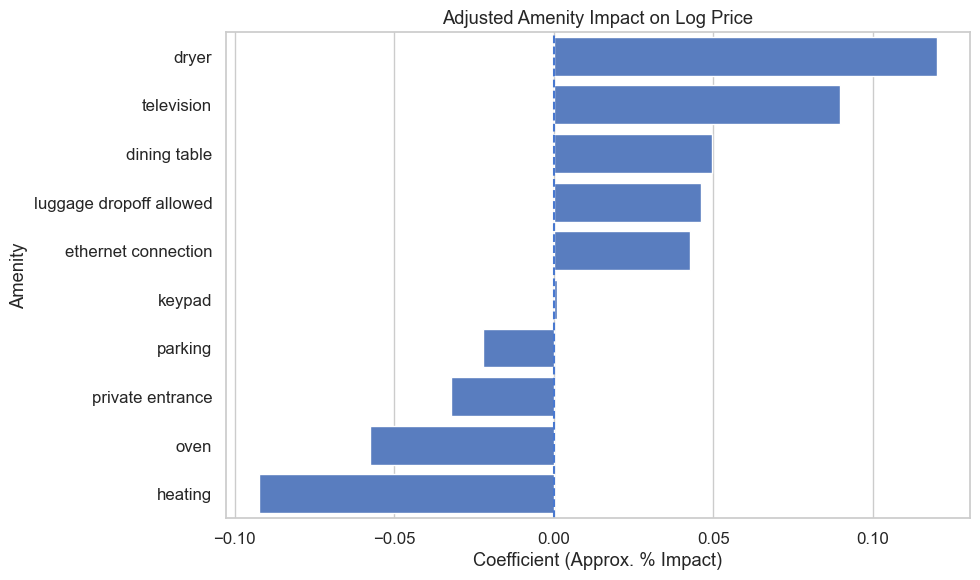

,Feature,Coefficient
115,dryer,0.120022
110,television,0.089700
117,dining table,0.049740
114,luggage dropoff allowed,0.046104
118,ethernet connection,0.042722
111,keypad,0.001049
112,parking,-0.022121
113,private entrance,-0.032256
116,oven,-0.057607
119,heating,-0.092285


In [40]:
top_results = run_adjusted_amenity_model(
    df_with_amenities,
    top_amenities,
    base_features,
    categorical_features
)

display(top_results)

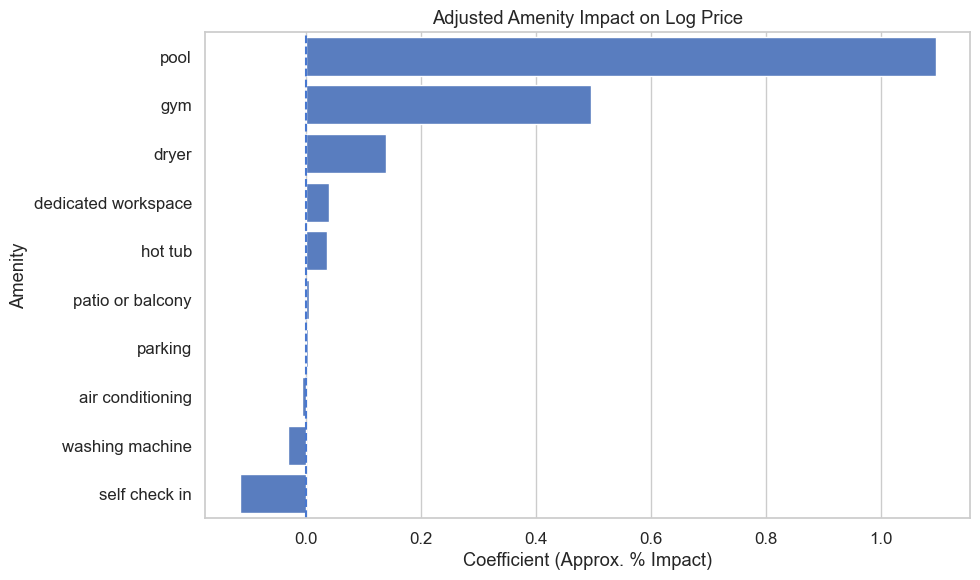

,Feature,Coefficient
117,pool,1.094497
119,gym,0.494747
113,dryer,0.139585
116,dedicated workspace,0.039758
118,hot tub,0.035732
115,patio or balcony,0.005355
114,parking,0.003949
110,air conditioning,-0.008100
112,washing machine,-0.031421
111,self check in,-0.115219


In [41]:
curated_amenities = [
    "air conditioning",
    "self check in",
    "washing machine",
    "dryer",
    "parking",
    "patio or balcony",
    "dedicated workspace",
    "pool",
    "hot tub",
    "gym"
]

curated_results = run_adjusted_amenity_model(
    df_with_amenities,
    curated_amenities,
    base_features,
    categorical_features
)

display(curated_results)

**Key Insights**
- Unadjusted amenity-price comparisons may capture broader listing characteristics rather than the true value of the amenity itself. For example, pools and gyms are typically found in larger or more premium properties, so part of their apparent price premium may reflect the type of property rather than the amenity alone.
- By curating the amenities, noise can be filtered out from rare or highly correlated features, making the results more interpretable and actionable for hosts deciding which amenities may justify additional investment.
- These approaches show that Airbnb amenities tend to fall into three broad groups: **baseline**, **functional**, **luxury**.
- **Baseline** amenities are expected, and have little pricing power (air conditioning, washing machine, patio or balcony).
- **Functional** amenities are a moderate value add. They might not be included everywhere, but can be sought out (dryer, dedicated workspace, luggage dropoff).
- **Luxury** amenities have the strongest pricing premiums and are not included as often (pools, hot tubs, gyms).
- Several amenities that appeared valuable in unadjusted comparisons became weaker after controlling for other listing characteristics, demonstrating the importance of multivariate analysis.

## 5. Feature Engineering
To make the data machine-learning–ready, key features were selected and organized. 
**Key steps:**
- Selected core predictors: `accommodates`, `bedrooms`, `bathrooms_count`, `beds`, `room_type`, `bathroom_type`,`neighborhood_cleansed`,`number_of_reviews`,`availability_365`, `curated_amenities`
- Encoded categorical variables using **OneHotEncoder**
- Scaled numeric variables using **StandardScaler**
- Log-transformed the target variable (`price`) to reduce skewness
- Created additional derived variables such as **price categories** for classification tasks
- Integrated all transformations into a unified **ColumnTransformer** for reproducibility

These engineered features helped improve model interpretability and performance.

### 5.1. Feature Selection

In [42]:
selected_features = ["accommodates","bedrooms","bathroom_count","beds",
                    "room_type","neighborhood_cleansed","bathroom_type",
                    "number_of_reviews","availability_365"]

numeric_features = ["accommodates","bedrooms","bathroom_count","beds","number_of_reviews","availability_365"]
categorical_features = ["room_type","neighborhood_cleansed","bathroom_type"]

model_features = selected_features + curated_amenities

# Multiple independent variables
X = df_with_amenities[model_features]

# Done on log transformed price
y = df_with_amenities["log_price"]

### 5.2. Train/Test Split

In [43]:
# Train/test split 80/20 split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"Training rows: {X_train.shape[0]:,}")
print(f"Testing rows: {X_test.shape[0]:,}")

Training rows: 8,940
Testing rows: 2,236


### 5.3. Preprocessing Pipeline

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numeric_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features),
        ("amenities","passthrough",curated_amenities)
    ]
)

print(f"Total input features before encoding: {X.shape[1]}")
X_processed = preprocessor.fit_transform(X_train)
print(f"Total engineered features after encoding: {X_processed.shape[1]}")

Total input features before encoding: 19
Total engineered features after encoding: 69


This preprocessing object was reused across all models to ensure consistent feature transformation and prevent train-test leakage.

##  6. Modeling and Evaluation

Multiple supervised learning models were implemented to predict both price (regression) and price categories (classification).

**Regression models:**
- Linear Regression (OLS)
- Ridge Regression (L2 regularization)
- Gradient Boosting Regressor
- Random Forest Regressor

**Classification models:**
- K-Nearest Neighbors (price category)

All models were built through unified **pipelines** that handle preprocessing, model training, and evaluation consistently.

In [45]:
# Set up logging
logging.basicConfig(
    format="%(asctime)s - %(levelname)s - %(message)s",
    level=logging.INFO
)

def create_pipeline(model_name, numeric_features, categorical_features, curated_amenities, task="regression"):
    """
    Create a preprocessing + model pipeline for different algorithms.
    
    Args: 
        model_name(str): The name of the type of model to be used.
        numeric_features(list): Numerical features to be used. 
        categorical_features(list): Categorical features to be used. 
        curated_amenities(list): Selected amenity features to be used.
        task(str): Machine learning method to be used. Default = regression
        
    Returns:
       sklearn.Pipeline: Model pipeline ready to be trained. 
    """
   
    # For models that require dense input
    requires_dense = model_name in ["gradient_boost"]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=not requires_dense  #  Dense only for models that need it
            ), categorical_features),
            ("amenities","passthrough",curated_amenities)
        ]
    )

    if task == "regression":
        if model_name == "linear":
            model = LinearRegression()
        elif model_name == "ridge":
            model = RidgeCV()
        elif model_name == "gradient_boost":
            model = HistGradientBoostingRegressor(random_state=42)
        elif model_name == "random_forest":
            model = RandomForestRegressor(random_state=42)
        else:
            raise ValueError(f"Unknown model name: {model_name}")

    elif task == "classification":
            model_name == "knn"
            model = KNeighborsClassifier(n_neighbors=9,weights="distance")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    return pipeline

In [46]:
def evaluate_regression(pipeline, X_train, X_test, y_train, y_test, task="regression", model_name="model", verbose=False):
    """
    Train, time, and evaluate a regression model pipeline with logging and metrics.
    
    Args:
        pipeline(sklearn.Pipeline): Preprocessed model pipeline.
        X_train(pandas.Dataframe): X training set.
        X_test(pandas.Dataframe): X testing set.
        y_train(pandas.Dataframe): Y training set.
        y_test(pandas.Dataframe): Y testing set. 
        task(str): Machine learning method to be used. Default = regression.
        model_name(str): The name of the model.
        verbose(bool): For logging purposes. Default = False.

    Returns:
        dictionary: Results of the model training and testing. 
        Returns the model name, root mean squared error (RMSE),
        R$^2$ error, and the time it took to run.
    """

    start_time = time.time()
    if verbose:
        logging.info(f"Starting training for {model_name.upper()}")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    duration = time.time() - start_time
    if verbose:
        logging.info(f" Completed {model_name.upper()} in {duration:.2f} seconds")

    if task == "regression":
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        results = {"model": model_name, "RMSE": rmse, "R$^2$": r2, "Time (s)": duration}
        if verbose:
            logging.info(f"{model_name.upper()} | RMSE: {rmse:.3f} | R²: {r2:.3f}")    
    return results

In [47]:
def evaluate_classification(pipeline, X_train, y_train, X_test, y_test, model_name, plot_cm=True, verbose=False):
    """
    Train, time, and evaluate a classification model pipeline with logging and metrics.

    Args:
        pipeline(sklearn.Pipeline): Preprocessed model pipeline.
        X_train(pandas.Dataframe): X training set.
        X_test(pandas.Dataframe): X testing set.
        y_train(pandas.Dataframe): Y training set.
        y_test(pandas.Dataframe): Y testing set. 
        model_name(str): The name of the model.
        plot_cm(bool): Plot confusion matrix. Default = True.
        verbose(bool): For logging purposes. Default = False.

    Returns: 
        dictionary: Results of the model training and testing. 
        Returns the model name, accuracy, F1 score, time, 
        and classification report pandas.Dataframe.
    """
    start = time.time()
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    duration = time.time() - start

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Optional: Plot confusion matrix
    if plot_cm:
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{model_name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    # Log results
    if verbose:
        logging.info(f"{model_name} | Accuracy: {acc:.3f} | F1: {f1:.3f} | Time: {duration:.2f}s")

    report = classification_report(y_test,y_pred,output_dict=True)

    report_df = (pd.DataFrame(report).transpose().round(3))

    display(report_df)

    # Return structured results
    return {
    "model": model_name,
    "Accuracy": acc,
    "F1": f1,
    "Time (s)": duration,
    "Classification Report": report_df}

In [48]:
def explain_model(pipeline, X_sample, model_name="model", max_display=20, verbose=False):
    """
    Generate SHAP values and feature importances for a fitted pipeline.
    
    Args:
        pipeline(sklearn.Pipeline): Preprocessed model pipeline
        X_sample(pandas.DataFrame): Subset of data to compute SHAP values (recommended: <= 1000 rows for speed).
        model_name(str): The name of the model.
        max_display(int): The number of top features to display in SHAP summary plots.
        verbose(bool): For logging purspoes. Default = False. 
    
    Returns:
        pandas.DataFrame: Combined feature importance and mean(|SHAP|) DataFrame.
    """
    # Log results
    if verbose:
        logging.info(f"Explaining model: {model_name}")
    start = time.time()

    # Get preprocessor and model
    preprocessor = pipeline.named_steps["preprocessor"]
    feature_names = preprocessor.get_feature_names_out()
    
    # Clean feature names for readability
    feature_names = [
    f.replace("cat__neighborhood_cleansed_", "")
     .replace("cat__room_type_", "")
     .replace("cat__bathroom_type_", "")
     .replace("num__", "")
     .replace("amenities__", "")
    for f in feature_names]
    
    model = list(pipeline.named_steps.values())[-1]  # assumes model is last step

    # Transform X for SHAP
    X_processed = preprocessor.transform(X_sample)

    # Compute feature importances
    try:
        fi = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False)
        if verbose:
            logging.info("Feature importances extracted successfully.")
    except AttributeError:
        fi = pd.DataFrame({"feature": feature_names, "importance": np.nan})
        if verbose:
            logging.warning("Model has no `feature_importances_` attribute.")

    # SHAP values
    if verbose:
        logging.info("Computing SHAP values...")
    # Convert sparse matrix to dense if needed
    if hasattr(X_processed, "toarray"):
        X_processed = X_processed.toarray()

    explainer = shap.Explainer(model, X_processed)
    shap_values = explainer(X_processed)

    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    shap_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)

    # Combine Results
    combined = pd.merge(fi, shap_df, on="feature", how="outer").fillna(0)
    combined = combined.sort_values("mean_abs_shap", ascending=False)

    # Visualization
    # Feature importance vs SHAP
    plt.figure(figsize=(10, 6))
    plt.barh(combined["feature"].head(max_display),
              combined["mean_abs_shap"].head(max_display),
              label="Mean |SHAP|", alpha=0.7)
    plt.barh(combined["feature"].head(max_display),
              combined["importance"].head(max_display),
              label="Model Importance", alpha=0.7)
    plt.gca().invert_yaxis()
    plt.xlabel("Value")
    plt.title(f"{model_name.upper()}: Feature Importance vs Mean |SHAP|")
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(
    "images/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
    )
    
    plt.show()
    
    # SHAP bar
    shap.summary_plot(shap_values,X_processed,feature_names=feature_names,plot_type="bar",max_display=max_display,show=False)

    plt.tight_layout()
    plt.savefig(
    "images/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
    )

    plt.show()
    
    # SHAO beeswarm
    shap.summary_plot(shap_values, X_processed, feature_names=feature_names, max_display=max_display, show = False)

    plt.tight_layout()
    plt.savefig(
    "images/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight")

    plt.show()

    
    duration = time.time() - start
        # Log results
    if verbose:
        logging.info(f"{model_name} SHAP explanation complete in {duration:.2f}s")

    return combined

### 6.1. Regression Modeling

In [49]:
models = ["linear", "ridge", "gradient_boost", "random_forest"]
fitted_pipelines = {}
results = []

for m in models:
    pipe = create_pipeline(m, numeric_features, categorical_features, curated_amenities, task="regression")
    res = evaluate_regression(pipe, X_train, X_test, y_train, y_test, task="regression", model_name=m,verbose = False)
    
    # Save results and model
    results.append(res)
    fitted_pipelines[m] = pipe  # store the trained pipeline

regression_results_df = pd.DataFrame(results).sort_values(by="R$^2$", ascending=False)

In [50]:
regression_results_df

,model,RMSE,R$^2$,Time (s)
3,random_forest,0.384279,0.729935,16.617537
2,gradient_boost,0.425664,0.668634,1.512034
1,ridge,0.535454,0.475654,0.063954
0,linear,0.535794,0.474989,0.050144


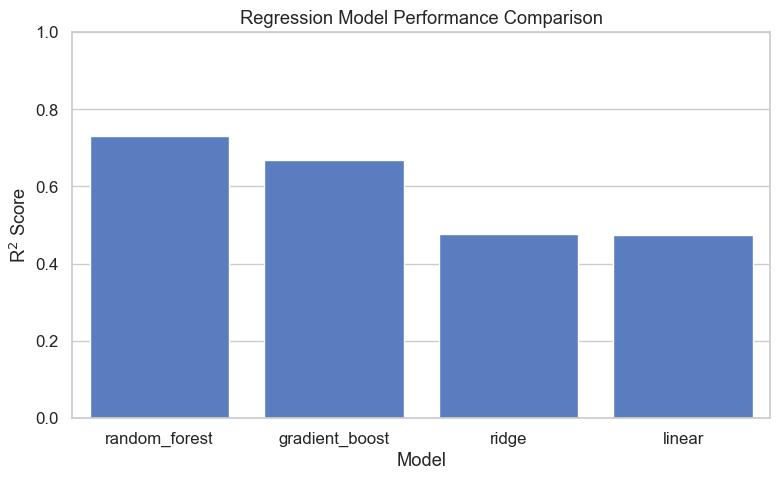

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=regression_results_df,
    x="model",
    y="R$^2$"
)

plt.title("Regression Model Performance Comparison")
plt.ylabel("R$^2$ Score")
plt.xlabel("Model")
plt.ylim(0,1)

plt.tight_layout()
plt.savefig(
    "images/model_comparison_r2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### 6.1.1. Regression Performance Comparison
Several regression models were evalutate to predict log-transformed Airbnb listing prices.
| Model | RMSE | $R^2$|
| :--- | :--- | :--- |
| Linear Regression | 0.536 | 0.475 |
| Ridge Regression | 0.535 | 0.476 |
| Gradient Boost | 0.426 | 0.669 |
| Random Forest Regressor  | 0.384 | 0.730 |

The linear and ridge regression models achieved moderate performance, explaining approximately 47% of price variance. The minimal improvement from Ridge regression suggests that multicollinearity was not a major limiting factor in the linear models.

Tree-based ensemble models substantially outperformed linear approaches. The Random Forest model achieved the strongest overall performance with an $R^2$ of 0.730, indicating that nonlinear interactions between location, property characteristics, and amenities play a significant role in Airbnb pricing.

These results suggest that Airbnb pricing dynamics are highly nonlinear and better captured through ensemble-based methods rather than simple linear relationships.

### 6.2. Classification Modeling

In [52]:
df_with_amenities.loc[:,"price_category"] = pd.qcut(selected_listings_df.loc[:,"log_price"],q=3,labels =["Low","Mid","High"])
# Done on log transformed price
y = df_with_amenities["price_category"]

# Multiple independent variables
X = df_with_amenities[model_features]

# Train/test split 80/20 split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

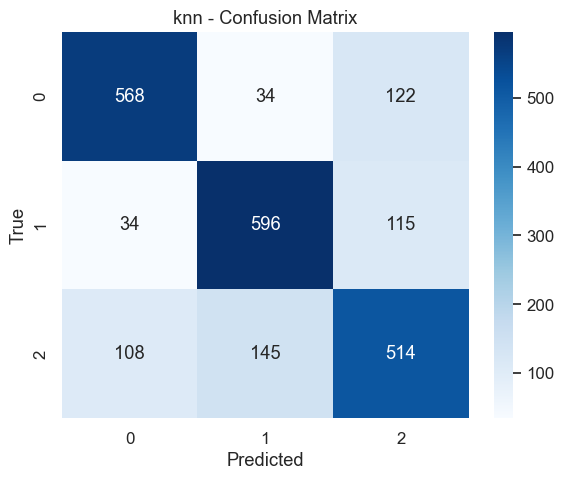

,precision,recall,f1-score,support
High,0.800,0.785,0.792,724.00
Low,0.769,0.800,0.784,745.00
Mid,0.684,0.670,0.677,767.00
accuracy,0.750,0.750,0.750,0.75
macro avg,0.751,0.752,0.751,2236.00
weighted avg,0.750,0.750,0.750,2236.00


In [53]:
models = ["knn"]
results = []
for name in models:
    pipeline = create_pipeline(name, numeric_features, categorical_features, curated_amenities, task="classification")
    res = evaluate_classification(pipeline, X_train, y_train, X_test, y_test, name)
    results.append(res)
classification_results_df = pd.DataFrame(results)

### 6.3. Model Evaluation & Comparison

Each model’s performance was evaluated using appropriate metrics.

**Regression Metrics:**
- Root Mean Squared Error (RMSE)
- $R^2$ Score

**Classification Metrics:**
- Accuracy
- F1 Score
- Confusion Matrix

**Key Insights:**
- Random Forest achieved the highest performance on log(price) prediction ($R^2 \approx 0.73$  , RMSE $\approx 0.38$)
- Gradient Boosting performed nearly as well with shorter runtime
- Linear and Ridge regressions underperformed relative to ensemble methods, suggesting that Airbnb prices are nonlinear
- The KNN classifier achieved $\approx 0.75$ accuracy in predicting listing price categories

These findings suggest that nonlinear interactions between listing characteristics, location, and amenities are important drivers of Airbnb pricing behavior.

##  7. Model Explainability (SHAP)

Model-specific and model-agnostic methods were used to interpret feature effects on predictions.

**Methods used:**
- Feature Importances from tree-based models
- Permutation Importance
- SHAP (SHapley Additive exPlanations) values for global and local interpretability

 98%|===================| 492/500 [00:38<00:00]        

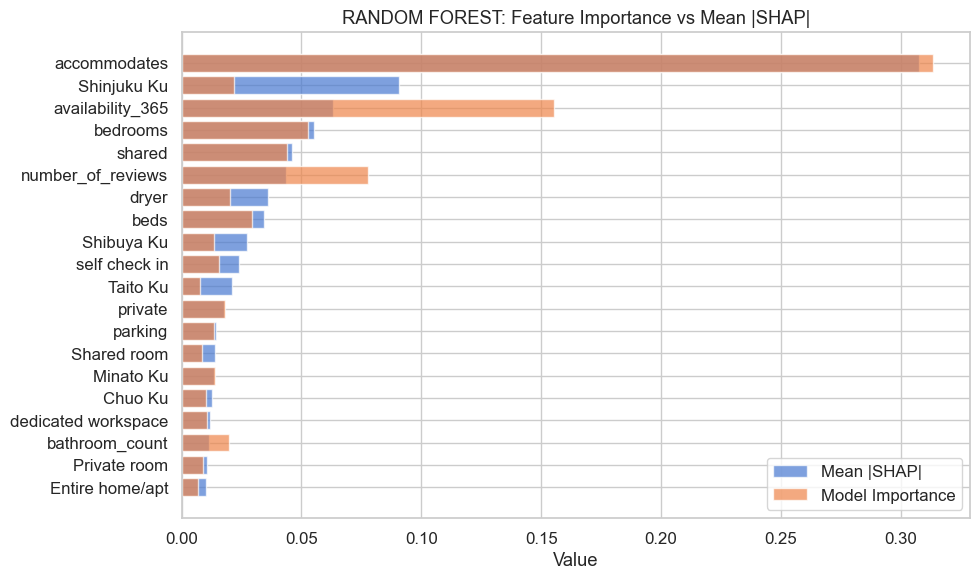

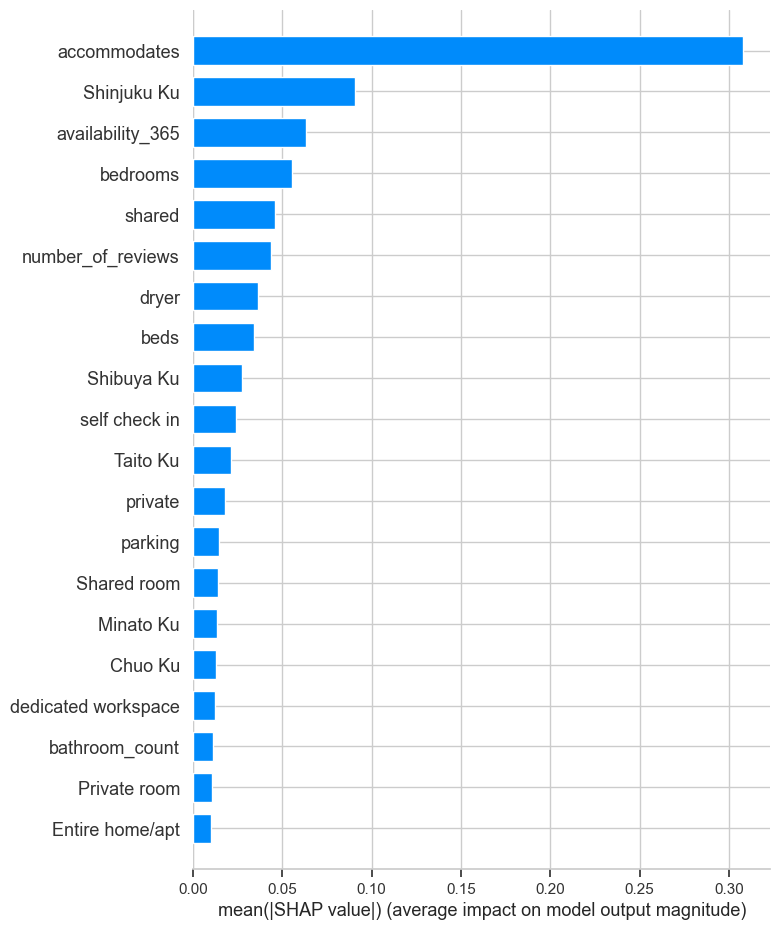

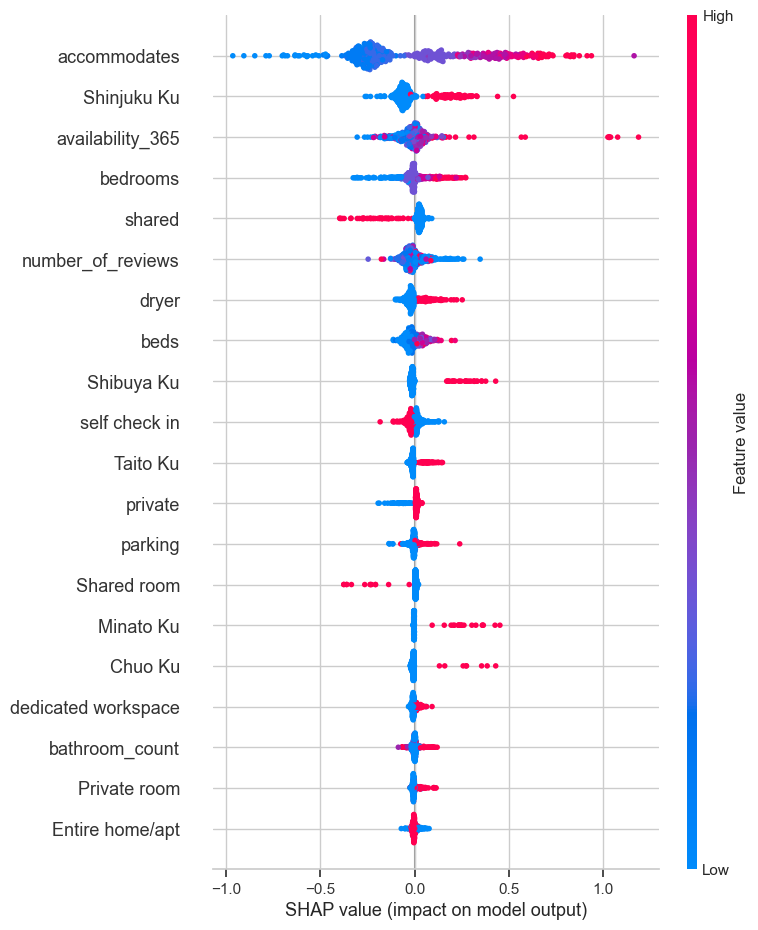

,feature,importance,mean_abs_shap
50,accommodates,0.313352,0.307764
43,Shinjuku Ku,0.022039,0.090704
52,availability_365,0.155479,0.063272
54,bedrooms,0.052808,0.055157
67,shared,0.043820,0.046127
61,number_of_reviews,0.077930,0.043630
57,dryer,0.020139,0.036164
55,beds,0.029448,0.034341
41,Shibuya Ku,0.013505,0.027354
66,self check in,0.015459,0.023862


In [54]:
# Our best model, lowest RMSE, highest R2
best_model_name = "random_forest"
best_pipeline = fitted_pipelines[best_model_name]

# Take a small random sample
X_sample = X_test.sample(500, random_state=42)

# Explain best model
explanation_df = explain_model(best_pipeline, X_sample, model_name="Random Forest", verbose = False)

# View top 20 features
display(explanation_df.head(20))

**Key Insights**
- `accommodates`, `Shinjuku Ku`, and `availability_365` are the most influencial predictors of price.
- Higher values in `accommodates` amd `bedrooms` tend to lead to higher listing prices.
- Being located in neighborhoods such as `Shinjuku Ku`, `Shibuya Ku`, and `Taito Ku` signicantly increased the price.
- These neighborhoods had low feature importance, but high SHAP values, suggesting that while the model did not split on them often, when they were included, they significantly affected the price.
- Some amenities proved more important to determining a listing's price, such as `dryer` and `self check in`.

## 8. Conclusion and Next Steps

### 8.1. Conclusion
This project explored the relationship between Airbnb listing characteristics and pricing within the Tokyo market. 

Initial exploratory analysis identified variation in prices across neighborhoods, room types, reviews, and time. Amenity-focused analysis revealed that premium amenities such as pools, gyms, and hot tubs were associated with higher prices, while common amenities showed limitied pricing influence.

Multiple machine learning models were developed to predict listing prices, as well as sort listings into pricing tiers. Among the evaluated models, Random Forest achieved the strongest performance, indicating that non-linear relationships and feature interactions play an important role in Airbnb pricing. 

Model explainability techniques provided additional insight into these relationships. SHAP analysis showed that accommodation capacity, neighborhood, availability, bedroom count, and room type consistently contributed more to price predictions than most individual amenities. While amenities remain valuable differentiators, their influence is generally secondary to location and listing characteristics. 

Overall, the results suggest that Airbnb pricing in Tokyo is driven primarily by property size, location, and listing type, with selected premium amenities providing additional value. 

### 8.2. Next Steps
There are several opportunites to further improve this analysis and further its scope:
- Incorporate sentiment analysis from guest reviews to investigate further factors affecting price.
- Explore temporal trends such as seasonality and holidays further to see if they lead to significant price fluctuations.
- Perform hyperparameter tuning to further optimize model performance.
- Investigate interaction between amenities and specific neighborhoods.
- Deploy the final model as an interactive web app that allows users to select features and get a price estimate. 